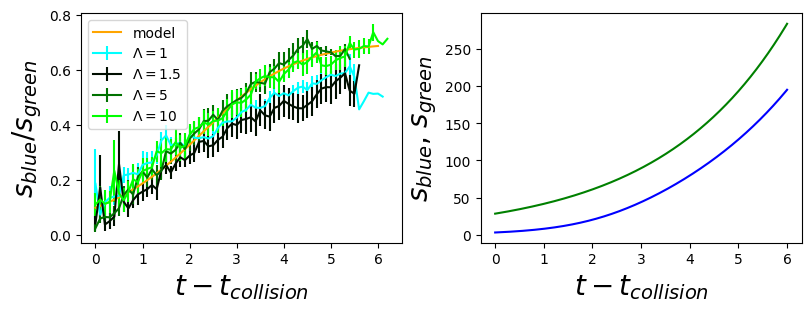

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import drag_functions as dfunc
from matplotlib import colors
import matplotlib as mpl

def plot_data(ax=None,error=False):
    Lambdas = [1,1.5,5,10]
    for i in Lambdas:
        if i ==1.5:
            df = pd.read_csv("C:\\Users\\lucca\\Desktop\\Friction_Biofilms\\Analysis\\data\\Inner_fraction_Lambda"+"1_5", sep='\t')
        else:
            df = pd.read_csv("C:\\Users\\lucca\\Desktop\\Friction_Biofilms\\Analysis\\data\\Inner_fraction_Lambda"+str(i), sep='\t')
        time = np.arange(0,len(df["avg"])*0.1 - 0.05,0.1)
        if error:
            ax.errorbar(time,df["avg"],yerr=df["stdev"],c=dfunc.colour_Lambda(i),label=r"$\Lambda="+str(i)+"$")
        else:
            ax.plot(time,df["avg"],c=dfunc.colour_Lambda(i),label=r"$\Lambda="+str(i)+"$")

def R_g(t,R0=10,tau=1.8):
    return R0*(2**(t/tau))

def s_green_evolution(time,R0=10,tau=1.8):
    sgreen = 2*np.pi*R_g(time,R0=R0,tau=tau)
    return sgreen

def dsb_dt_sum(t,sblue,mu=5,av_l=4,R0=10,phi0=np.pi/2,tau=1.8):
    n = sblue/(2*av_l)
    dsdt = 1
    for i in range(1,int(n)):
        if i*av_l/(R_g(t,R0=R0,tau=tau)) < phi0:
            dsdt += np.cos(i*av_l/(R_g(t,R0=R0,tau=tau)))
    return dsdt*2*mu

def dsb_dt_int(t,sblue,mu=5,av_l=4,R0=10,tau=1.8):
    Rg = R_g(t,R0=R0,tau=tau)
    imax = sblue/(2*av_l)
    return 2*mu*(Rg/av_l)*np.sin(imax*av_l/Rg)

def s_blue_evolution(time,s0,dt,mu=5,av_l=4,R0=10,tau=1.8):
    n_timesteps = len(time)
    sblue = np.zeros(n_timesteps)
    sblue[0] = s0
    for t in range(1,n_timesteps):
        dsdt = dsb_dt_int(time[t],sblue[t-1],mu=mu,av_l=av_l,R0=R0,tau=tau)
        sblue[t] = sblue[t-1] +dsdt*dt
    return sblue

def evolve_time(time,frac_s0=0.05,dt=0.0001,mu=5,av_l=4,R0=10,tau=1.8):
    sgreen = s_green_evolution(time,R0=R0,tau=tau)
    s0 = sgreen[0]*frac_s0
    sblue = s_blue_evolution(time,s0,dt,mu=mu,av_l=av_l,R0=R0,tau=tau)
    return sgreen,sblue


def define_axis(axes):
    axes[0].set_ylabel("$s_{blue}/s_{green}$",fontsize = 20)
    axes[0].set_xlabel("$t-t_{collision}$",fontsize = 20)
    axes[0].legend()


    axes[1].set_ylabel("$s_{blue}$, $s_{green}$",fontsize = 20)
    axes[1].set_xlabel("$t-t_{collision}$",fontsize = 20)


fig, axes = plt.subplots(1,2, figsize=(8,3), constrained_layout=True, facecolor='w')

dt = 0.0001
tend = 6
time = np.arange(0,tend,dt)

frac_s0 = 0.10
mu=5
av_l=4.75
tau=1.8
t0=3

R0 = np.sqrt(2)*2**(t0/tau)
    
sgreen,sblue = evolve_time(time,frac_s0=frac_s0,dt=dt,mu=mu,av_l=av_l,R0=R0,tau=tau)
axes[1].plot(time,sblue,c="b")
axes[1].plot(time,sgreen,c="g")
plot_data(axes[0],True)

axes[0].plot(time,sblue/sgreen,c="orange",label="model")

define_axis(axes)

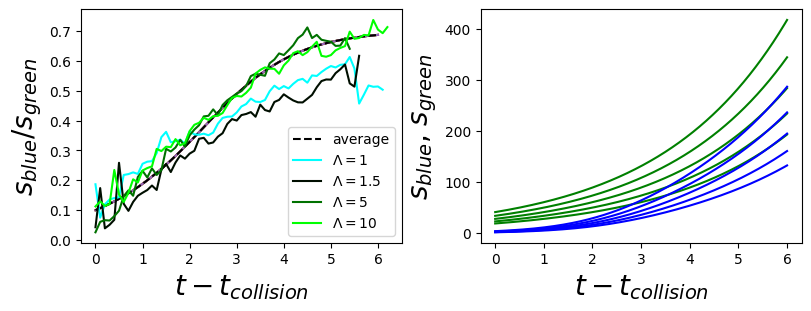

In [9]:
fig, axes = plt.subplots(1,2, figsize=(8,3), constrained_layout=True, facecolor='w')

dt = 0.0001
tend = 6
time = np.arange(0,tend,dt)

frac_s0 = 0.1
mu=5
av_l=4.75
tau=1.8

x = np.linspace(2,4,5)

fraction = np.zeros((len(time),len(x)))
for i in range(0,len(x)):
    R0 = np.sqrt(2)*2**(x[i]/tau)
    
    sgreen,sblue = evolve_time(time,frac_s0=frac_s0,dt=dt,mu=mu,av_l=av_l,R0=R0,tau=tau)

    fraction[:,i] = sblue/sgreen
    
    axes[0].plot(time,fraction[:,i])
    axes[1].plot(time,sblue,c="b")
    axes[1].plot(time,sgreen,c="g")

av_fraction = np.mean(fraction,axis=1)
err_fraction = np.std(fraction,axis=1)/np.sqrt(len(x))
axes[0].plot(time,av_fraction,"--",c="k",label="average")
axes[0].fill_between(time, av_fraction-err_fraction, av_fraction+err_fraction, facecolor='k',alpha=0.2)

plot_data(axes[0])
define_axis(axes)

average starting farction = 0.1


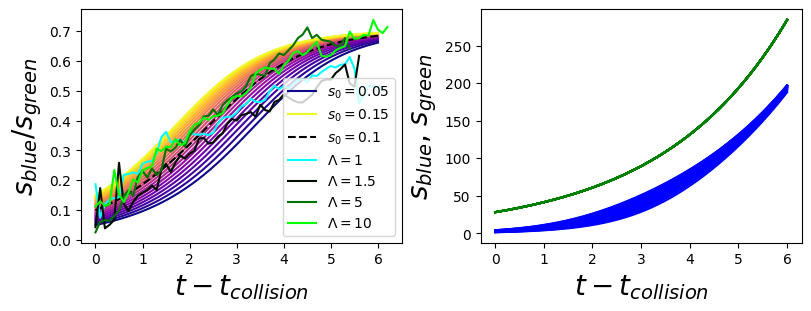

In [10]:
fig, axes = plt.subplots(1,2, figsize=(8,3), constrained_layout=True, facecolor='w')

dt = 0.0001
tend = 6
time = np.arange(0,tend,dt)

frac_s0 = 0.05
mu=5
av_l=4.75
t0 = 3
tau=1.8

x = np.linspace(0.05,0.15,20)


n_lines = 20
cmap = mpl.colormaps['plasma']

# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, n_lines))


fraction = np.zeros((len(time),len(x)))
for i in range(0,len(x)):
    R0 = np.sqrt(2)*2**(t0/tau)
    
    sgreen,sblue = evolve_time(time,frac_s0=x[i],dt=dt,mu=mu,av_l=av_l,R0=R0,tau=tau)
    axes[1].plot(time,sblue,c="b")
    axes[1].plot(time,sgreen,c="g")

    fraction[:,i] = sblue/sgreen
    if (i==0) or (i==len(x)-1):
        axes[0].plot(time,fraction[:,i],c=colors[i],label=f"$s_0 = {round(x[i],2)}$")
    else:
        axes[0].plot(time,fraction[:,i],c=colors[i])
    


av_fraction = np.mean(fraction,axis=1)
print("average starting farction =",av_fraction[0])
err_fraction = np.std(fraction,axis=1)/np.sqrt(len(x))
axes[0].plot(time,av_fraction,"--",c="k",label="$s_0 = 0.1$")

plot_data(axes[0])
define_axis(axes)

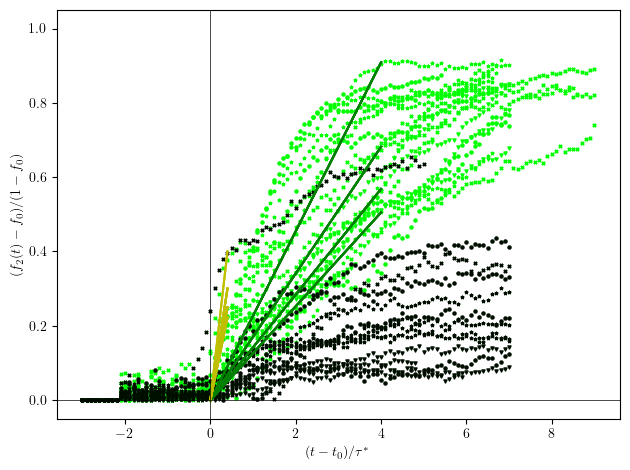

In [11]:
import Plot_channels as pch
import plotting_functions as pfunc
data_loc = "C:\\Users\\lucca\\Desktop\\GeneratedOutput\\SimOutput\\data\\"
GRequal_L0_1IC1_1 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda0_1INITIAL_RATIO1_1",5)
GRequal_L0_1IC1_2 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda0_1INITIAL_RATIO1_2",5)
GRequal_L0_1IC1_4 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda0_1INITIAL_RATIO1_4",5)
GRequal_L0_1IC1_9 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda0_1INITIAL_RATIO1_9",5)
GRequal_compare0_1 = GRequal_L0_1IC1_1+GRequal_L0_1IC1_2+GRequal_L0_1IC1_4+GRequal_L0_1IC1_9

GRequal_L1_5IC1_1 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda1_5INITIAL_RATIO1_1",5)
GRequal_L1_5IC1_2 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda1_5INITIAL_RATIO1_2",5)
GRequal_L1_5IC1_4 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda1_5INITIAL_RATIO1_4",5)
GRequal_L1_5IC1_9 = pfunc.repeat_files(data_loc+"InfiniteChannel\\40microns\\Lambda1_5INITIAL_RATIO1_9",5)
GRequal_compare1_5 = GRequal_L1_5IC1_1+GRequal_L1_5IC1_2+GRequal_L1_5IC1_4+GRequal_L1_5IC1_9


def linear(time,f0,ratio=10):
    mu = 5
    average_l = 4
    denominator = 1/(1+ratio)
    return mu*time*denominator/(average_l*(1-f0))
    

ratio=[]
data_dirs = GRequal_compare0_1+[GRequal_compare1_5[0]]+GRequal_compare1_5[4:-2]+[GRequal_compare1_5[-1]]
t0=0
tf=0

for data_dir in data_dirs:
    r,t,t_star,f0 = pfunc.cells_change_fraction(data_dir,norm=False,t_star=True)
    if r == 10.0:
        time = np.linspace(0,4,2000)
        plt.plot(time,linear(time,f0,r),"g")
    else:
        time = np.linspace(0,0.4,2000)
        plt.plot(time,linear(time,f0,r),"y")
        
    if t[0]<t0:
        t0 = t[0]
    if t[-1]>tf:
        tf = t[-1]
    ratio += [r]

t0 -=t0*0.1
tf -=tf*0.1
    
plt.axline((0, 0), (0,1), linewidth=0.5, color='k')
plt.axline((t0, 0), (tf,0), linewidth=0.5, color='k')

plt.xlabel(r"$(t-t_0)/\tau^*$")
plt.ylabel(r"$(f_2(t) - f_0)/(1-f_0)$")

plt.tight_layout()

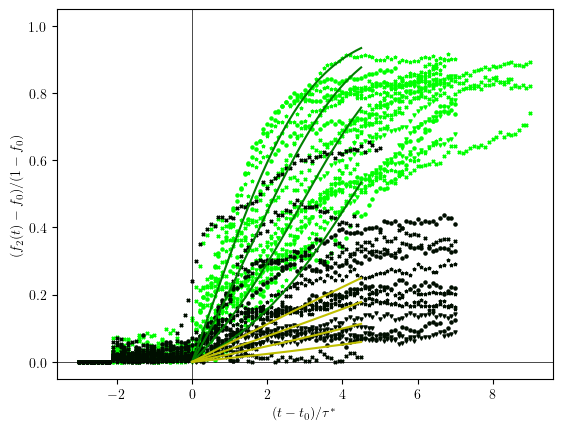

In [71]:
ratio=[]
data_dirs = GRequal_compare0_1+GRequal_compare1_5[:-2]+[GRequal_compare1_5[-1]]
t0=0
tf=0
for data_dir in data_dirs:
    r,t = pfunc.cells_change_fraction(data_dir,norm=False)
    if t[0]<t0:
        t0 = t[0]
    if t[-1]>tf:
        tf = t[-1]
    ratio += [r]

t0 -=t0*0.1
tf -=tf*0.1
    
plt.axline((0, 0), (0,1), linewidth=0.5, color='k')
plt.axline((t0, 0), (tf,0), linewidth=0.5, color='k')

plt.xlabel(r"$(t-t_0)/\tau^*$")
plt.ylabel(r"$(f_2(t) - f_0)/(1-f_0)$")




def df_dt(f,r,A=1):
    alpha=1/4
    r = r**alpha
    return (A)*f*(1-1/(r*(1-f) + f))

def f_evolution(time,dt,f0=0.1,ratio=10):
    n_timesteps = len(time)
    f = np.zeros(n_timesteps)
    f[0] = f0
    
    #parameters
    av_l = 4.5
    mu = 5
    k = 5
    A = mu/(av_l)
    
    for t in range(1,n_timesteps):
        dfdt = df_dt(f[t-1],ratio,A)
        f[t] = f[t-1] +dfdt*dt
    return f

dt = 0.0001
time = np.arange(0,4.5,dt)
f0_list = [0.1,0.2,1/3,0.5]

ratio = 10
for f0 in f0_list:
    f = f_evolution(time,dt,f0,ratio)
    f = (f-f0)/(1-f0)
    plt.plot(time,f,c="g")

ratio = 1.5
for f0 in f0_list:
    f = f_evolution(time,dt,f0,ratio)
    f = (f-f0)/(1-f0)
    plt.plot(time,f,c="y")

Text(0, 0.5, '$df_2^{leaving}/dt$')

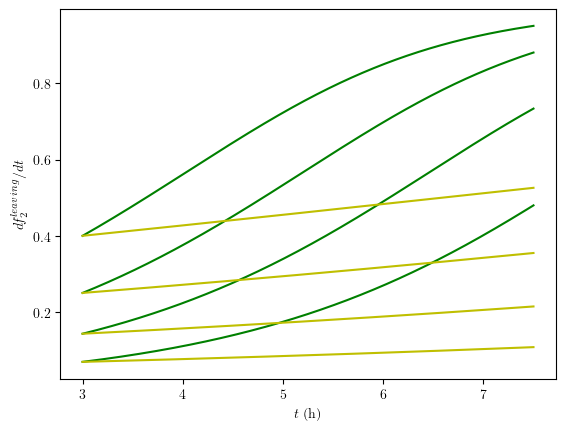

In [72]:
dt = 0.00001
time = np.arange(3,7.5,dt)
f0_list = [0.1,0.2,1/3,0.5]

ratio = 10
for f0 in f0_list:
    f = f_evolution(time,dt,f0,ratio)
    dfdt_leaving = f*(1/(r*(1-f) + f))
    plt.plot(time,dfdt_leaving,c="g")

ratio = 1.5
for f0 in f0_list:
    f = f_evolution(time,dt,f0,ratio)
    dfdt_leaving= f*(1/(r*(1-f) + f))
    plt.plot(time,dfdt_leaving,c="y")

plt.xlabel("$t$ (h)")
plt.ylabel(r"$df_2^{leaving}/dt$")